Research Question 8: How do the number and average timing of substitutions affect the number of shots on goal in the second half?

Retrieving the Data:

In [2]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from scipy import stats
import json
import numpy as np

import soccerdata as sd 

data = sd.WhoScored(leagues="GER-Bundesliga", seasons="2024/2025", headless=True)

# Creating a list of all the game IDs of the Bundesliga season 2024/2025
game_ids = data.read_schedule()["game_id"].to_list()

events = data.read_events(match_id=game_ids)

substitutions = events[events["type"]=="SubstitutionOff"]
substitutions["minutes_played"] = (90 - substitutions["minute"]).clip(lower=0)

shot_types = ["Goal", "MissedShots", "SavedShot", "ShotOnPost"]
shots = events[(events["type"].isin(shot_types)) & (events["period"] == "SecondHalf")]

# Aggregate all the shots per match and team

shot_count = shots.groupby(["game_id", "team_id"]).size().reset_index(name="total_shots_secondHalf")

sub_count = substitutions.groupby(["game_id", "team_id"]).agg(
    sub_count=("type", "count"),
    avg_sub=("minute", "mean")
).reset_index()

total_sub_time = substitutions.groupby(["game_id", "team_id"])["minutes_played"].sum().reset_index(name="total_sub_time")

df_RQ8 = pd.merge(sub_count, shot_count, on=["game_id", "team_id"], how="left").fillna(0)

df_RQ8 = pd.merge(df_RQ8, total_sub_time, on=["game_id", "team_id"], how="left").fillna(0)

df_RQ8.to_json("RQ8.json", orient="records", indent=4)
df_RQ8.to_csv("RQ8.csv", index=False)




[03/12/26 17:00:12] INFO     No custom team name replacements found. You can configure these in       ]8;id=36192;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=790580;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\hinri\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=990269;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=875438;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py#198\198]8;;\
                             C:\Users\hinri\soccerdata\config\league_dict.json.                                    

                    INFO     Saving cached data to C:\Users\hinri\soccerdata\data\WhoScored          ]8;id=94589;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=170048;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py#249\249]8;;\

[03/12/26 17:00:17] INFO     Retrieving calendar for GER-Bundesliga 2425                           ]8;id=504301;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=786206;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#365\365]8;;\

                    INFO     [1/10] Retrieving fixtures for GER-Bundesliga 2425                    ]8;id=812250;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=429446;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#396\396]8;;\

...

                    INFO     [303/306] Retrieving game with id=1834451                             ]8;id=300149;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=355602;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [304/306] Retrieving game with id=1834459                             ]8;id=434805;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=410250;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [305/306] Retrieving game with id=1834447                             ]8;id=978083;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=297859;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [306/306] Retrieving game with id=1834463                             ]8;id=688619;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=543311;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

[03/12/26 17:00:41] WARNING  C:\Users\hinri\AppData\Local\Temp\ipykernel_6656\2790203522.py:18:     warnings.py:110
                             SettingWithCopyWarning:                                                               
                             A value is trying to be set on a copy of a slice from a DataFrame.                    
                             Try using .loc = value instead                                                        
                                                                                                                   
                             See the caveats in the documentation:                                                 
                             https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#                
                             returning-a-view-versus-a-copy                                                        
                               substitutions["minutes_played"] = (90 -                                             
                             substitutions["minute"]).clip(lower=0)                                                
                                                                                                                   

Creating the visualization:

[03/12/26 17:03:48] INFO     Using categorical units to plot a list of strings that are all         ]8;id=981678;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=913766;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py#223\223]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=753224;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=763473;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\category.py#223\223]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

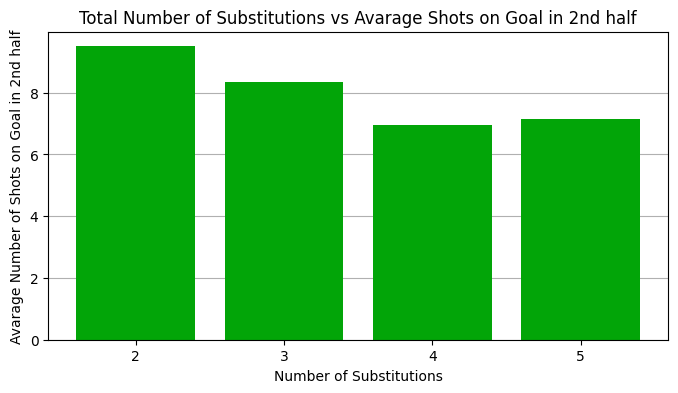

In [9]:
avg_shots = df_RQ8[df_RQ8["sub_count"].isin([2, 3, 4, 5])].groupby("sub_count")["total_shots_secondHalf"].mean()

plt.figure(figsize=(8, 4))

plt.bar(["2","3","4","5"],avg_shots.values, color="#02A508")

ax = plt.gca()
ax.set_axisbelow(True)

plt.grid(axis="y")

plt.title("Total Number of Substitutions vs Avarage Shots on Goal in 2nd half")
plt.xlabel("Number of Substitutions")
plt.ylabel("Avarage Number of Shots on Goal in 2nd half")

plt.savefig("SubCount.png")

plt.show()

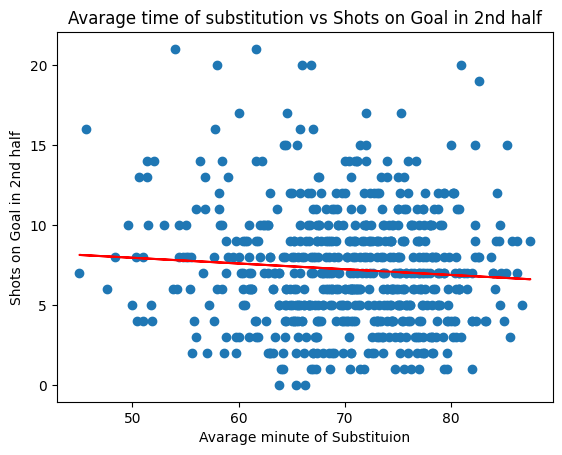

In [ ]:
X_avg = df_RQ8["avg_sub"]

m, b = np.polyfit(X_avg, Y, 1)

plt.figure()
plt.scatter(X_avg, Y, alpha=1)
plt.plot(X_avg, m*X_avg + b, color="red")
plt.title("Avarage time of substitution vs Shots on Goal in 2nd half")
plt.xlabel("Avarage minute of Substituion")
plt.ylabel("Shots on Goal in 2nd half")


plt.savefig("MeanSub.png")

plt.show()

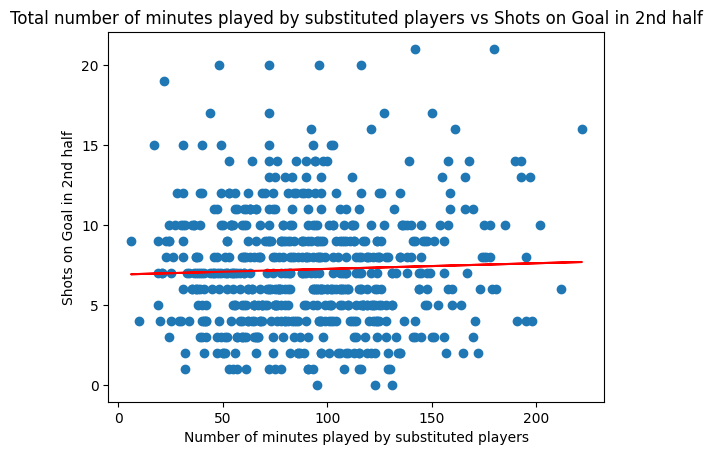

In [ ]:
X_sum = df_RQ8["total_sub_time"]

m, b = np.polyfit(X_sum, Y, 1)

plt.figure()
plt.scatter(X_sum, Y, alpha=1)
plt.plot(X_sum, m*X_sum + b, color="red")
plt.title("Total number of minutes played by substituted players vs Shots on Goal in 2nd half")
plt.xlabel("Number of minutes played by substituted players")
plt.ylabel("Shots on Goal in 2nd half")


plt.savefig("TotalTime.png")

plt.show()